In [1]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.7.0
0.13.2


#### 라이브러리 및 경로 설정

In [7]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

data_dir = os.path.join(os.getenv("HOME"), 'work/weat/data')
okt = Okt()

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt',
             'synopsis_horror.txt', 'synopsis_etc.txt', 'synopsis_documentary.txt',
             'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
             'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt',
             'synopsis_animation.txt', 'synopsis_action.txt', 'synopsis_adventure.txt',
             'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']

genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마',
              '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
              '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

print("설정 완료!")

설정 완료!


#### 형태소 분석 함수 정의

In [8]:
def read_token_str(file_name):
    """TF-IDF용: 파일 전체를 하나의 명사 문자열로 반환"""
    result = []
    with open(data_dir + '/' + file_name, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for line in lines:
        if not line.strip(): continue
        tokens = okt.pos(line, stem=True, norm=True)
        nouns = [t[0] for t in tokens if t[1] == "Noun"]
        result.extend(nouns)
    return ' '.join(result)

def read_token_list(file_name):
    """Word2Vec용: 줄별 명사 리스트로 반환"""
    result = []
    with open(data_dir + '/' + file_name, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for line in lines:
        if not line.strip(): continue
        tokens = okt.pos(line, stem=True, norm=True)
        nouns = [t[0] for t in tokens if t[1] == "Noun"]
        if nouns:
            result.append(nouns)
    return result

print("함수 정의 완료!")

함수 정의 완료!


#### Tokenizing

In [10]:
print("예술영화 처리 중...")
art_str  = read_token_str(art_txt)
art_list = read_token_list(art_txt)
print("예술영화 완료!")

print("일반영화 처리 중...")
gen_str  = read_token_str(gen_txt)
gen_list = read_token_list(gen_txt)
print("일반영화 완료!")

genre_str_list   = []
genre_token_list = []

for i, txt in enumerate(genre_txt):
    print(f"[{i+1}/{len(genre_txt)}] {genre_name[i]} 처리 중...")
    genre_str_list.append(read_token_str(txt))
    genre_token_list.append(read_token_list(txt))

print("\n토크나이징 전체 완료!")

예술영화 처리 중...
예술영화 완료!
일반영화 처리 중...
일반영화 완료!
[1/21] SF 처리 중...
[2/21] 가족 처리 중...
[3/21] 공연 처리 중...
[4/21] 공포(호러) 처리 중...
[5/21] 기타 처리 중...
[6/21] 다큐멘터리 처리 중...
[7/21] 드라마 처리 중...
[8/21] 멜로로맨스 처리 중...
[9/21] 뮤지컬 처리 중...
[10/21] 미스터리 처리 중...
[11/21] 범죄 처리 중...
[12/21] 사극 처리 중...
[13/21] 서부극(웨스턴) 처리 중...
[14/21] 성인물(에로) 처리 중...
[15/21] 스릴러 처리 중...
[16/21] 애니메이션 처리 중...
[17/21] 액션 처리 중...
[18/21] 어드벤처 처리 중...
[19/21] 전쟁 처리 중...
[20/21] 코미디 처리 중...
[21/21] 판타지 처리 중...

토크나이징 전체 완료!


#### Word2Vec 학습

In [11]:
# 모든 토큰 합치기
all_tokens = art_list + gen_list
for g in genre_token_list:
    all_tokens += g

# Word2Vec 학습
model = Word2Vec(
    all_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0,
    workers=4
)
print(f"Word2Vec 학습 완료! 학습된 단어 수: {len(model.wv)}")

# ── 평가기준: most_similar() 결과 검증 ───────────────────
print("\n=== most_similar() 결과 검증 ===")
test_words = ['영화', '감독', '사랑', '액션', '공포']
for word in test_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' 유사 단어:")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")
    else:
        print(f"'{word}': 단어 없음(OOV)")

# 모델 저장
model.save(data_dir + '/word2vec_synopsis.model')
print("\n모델 저장 완료!")

Word2Vec 학습 완료! 학습된 단어 수: 30012

=== most_similar() 결과 검증 ===

'영화' 유사 단어:
  작품: 0.7966
  다큐멘터리: 0.7787
  영화로: 0.7435
  드라마: 0.6987
  코미디: 0.6806

'감독' 유사 단어:
  각본: 0.6998
  영화로: 0.6823
  신작: 0.6781
  영화감독: 0.6746
  데뷔: 0.6622

'사랑' 유사 단어:
  만남: 0.5933
  진심: 0.5816
  애정: 0.5706
  감정: 0.5693
  행복: 0.5680

'액션' 유사 단어:
  블록버스터: 0.8479
  리얼: 0.8282
  어드벤처: 0.8160
  호러: 0.8101
  무협: 0.8075

'공포' 유사 단어:
  극도: 0.7016
  엄습: 0.6963
  혼란: 0.6911
  현상: 0.6824
  광기: 0.6748

모델 저장 완료!


#### TF-IDF 및 WEAT 함수 정의

In [12]:
def get_top_words(text1, text2, N=15):
    """
    TF-IDF 차이값으로 각 문서의 고유 대표 단어 추출
    - 단순 TF-IDF 상위 N개 대신 차이값을 사용해 중복 제거
    - text1 고유: text1 TF-IDF - text2 TF-IDF 상위 N개
    - text2 고유: text2 TF-IDF - text1 TF-IDF 상위 N개
    """
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text1, text2])
    vocab = vectorizer.get_feature_names_out()

    tfidf_1 = np.array(X[0].todense()).flatten()
    tfidf_2 = np.array(X[1].todense()).flatten()

    top_1 = vocab[np.argsort(tfidf_1 - tfidf_2)[::-1][:N]].tolist()
    top_2 = vocab[np.argsort(tfidf_2 - tfidf_1)[::-1][:N]].tolist()

    # 명시적 중복 제거
    top_1_unique = [w for w in top_1 if w not in top_2]
    top_2_unique = [w for w in top_2 if w not in top_1]

    return top_1_unique, top_2_unique

def words_to_vecs(words, model):
    """단어 리스트를 벡터 배열로 변환 (OOV 제외)"""
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.array(vecs) if vecs else None

def cos_sim(w, A):
    """단어 w와 단어 집합 A의 평균 코사인 유사도"""
    sims = [np.dot(w, a) / (np.linalg.norm(w) * np.linalg.norm(a)) for a in A]
    return np.mean(sims)

def weat_score(X_vecs, Y_vecs, A_vecs, B_vecs):
    """
    WEAT Score = Σs(x,A,B) - Σs(y,A,B)
    양수(+): X(예술영화)가 A(해당 장르)에 더 가까움
    음수(-): Y(일반영화)가 A(해당 장르)에 더 가까움
    """
    s_X = np.sum([cos_sim(x, A_vecs) - cos_sim(x, B_vecs) for x in X_vecs])
    s_Y = np.sum([cos_sim(y, A_vecs) - cos_sim(y, B_vecs) for y in Y_vecs])
    return s_X - s_Y

print("함수 정의 완료!")

함수 정의 완료!


#### Target 단어set 구성

In [13]:
# ── 평가기준: 대표성 있는 단어 셋 생성 ───────────────────
target_art_words, target_gen_words = get_top_words(art_str, gen_str, N=15)

target_art_vecs = words_to_vecs(target_art_words, model)
target_gen_vecs = words_to_vecs(target_gen_words, model)

print(f"Target 예술영화 ({len(target_art_words)}개): {target_art_words}")
print(f"Target 일반영화 ({len(target_gen_words)}개): {target_gen_words}")

# 중복 여부 검증
overlap = set(target_art_words) & set(target_gen_words)
print(f"\n중복 단어: {overlap if overlap else '없음'}")

Target 예술영화 (15개): ['사랑', '시작', '과연', '세상', '마을', '마음', '인생', '위해', '가족', '음악', '아빠', '사람', '모든', '서로', '파리']
Target 일반영화 (15개): ['영화제', '국제', '서울', '애니메이션', '작품', '단편', '남편', '연출', '의도', '부문', '여성', '관계', '섹스', '생각', '부천']

중복 단어: 없음


#### WEAT score 계산

In [14]:
# ── 평가기준: WEAT score 계산 ─────────────────────────────
weat_scores = []

print("=== 장르별 WEAT Score 계산 ===")
for i, (g_str, g_name) in enumerate(zip(genre_str_list, genre_name)):

    # 해당 장르 vs 나머지 장르 합친 문서로 Attribute 단어 셋 구성
    other_str = ' '.join([s for j, s in enumerate(genre_str_list) if j != i])
    attr_genre_words, attr_other_words = get_top_words(g_str, other_str, N=15)

    attr_genre_vecs = words_to_vecs(attr_genre_words, model)
    attr_other_vecs = words_to_vecs(attr_other_words, model)

    if (target_art_vecs is None or target_gen_vecs is None
            or attr_genre_vecs is None or attr_other_vecs is None):
        print(f"[SKIP] {g_name}: 벡터 없음")
        weat_scores.append(0)
        continue

    score = weat_score(target_art_vecs, target_gen_vecs,
                       attr_genre_vecs, attr_other_vecs)
    weat_scores.append(score)
    print(f"[{i+1:2}/{len(genre_name)}] {g_name:15}: {score:+.4f}  "
          f"{'← 예술 편향' if score > 0 else '← 일반 편향'}")

print("\nWEAT Score 계산 완료!")

=== 장르별 WEAT Score 계산 ===
[ 1/21] SF             : +2.0545  ← 예술 편향
[ 2/21] 가족             : +1.6784  ← 예술 편향
[ 3/21] 공연             : -1.1213  ← 일반 편향
[ 4/21] 공포(호러)         : +2.9376  ← 예술 편향
[ 5/21] 기타             : -6.1743  ← 일반 편향
[ 6/21] 다큐멘터리          : -2.6522  ← 일반 편향
[ 7/21] 드라마            : -1.4177  ← 일반 편향
[ 8/21] 멜로로맨스          : +1.9054  ← 예술 편향
[ 9/21] 뮤지컬            : -0.8857  ← 일반 편향
[10/21] 미스터리           : +1.9391  ← 예술 편향
[11/21] 범죄             : +1.6110  ← 예술 편향
[12/21] 사극             : +0.4236  ← 예술 편향
[13/21] 서부극(웨스턴)       : +1.3037  ← 예술 편향
[14/21] 성인물(에로)        : -1.0824  ← 일반 편향
[15/21] 스릴러            : +2.7959  ← 예술 편향
[16/21] 애니메이션          : -3.8704  ← 일반 편향
[17/21] 액션             : +1.9728  ← 예술 편향
[18/21] 어드벤처           : +2.2756  ← 예술 편향
[19/21] 전쟁             : +0.3696  ← 예술 편향
[20/21] 코미디            : +2.6225  ← 예술 편향
[21/21] 판타지            : +1.8411  ← 예술 편향

WEAT Score 계산 완료!


#### 히트맵 시각화

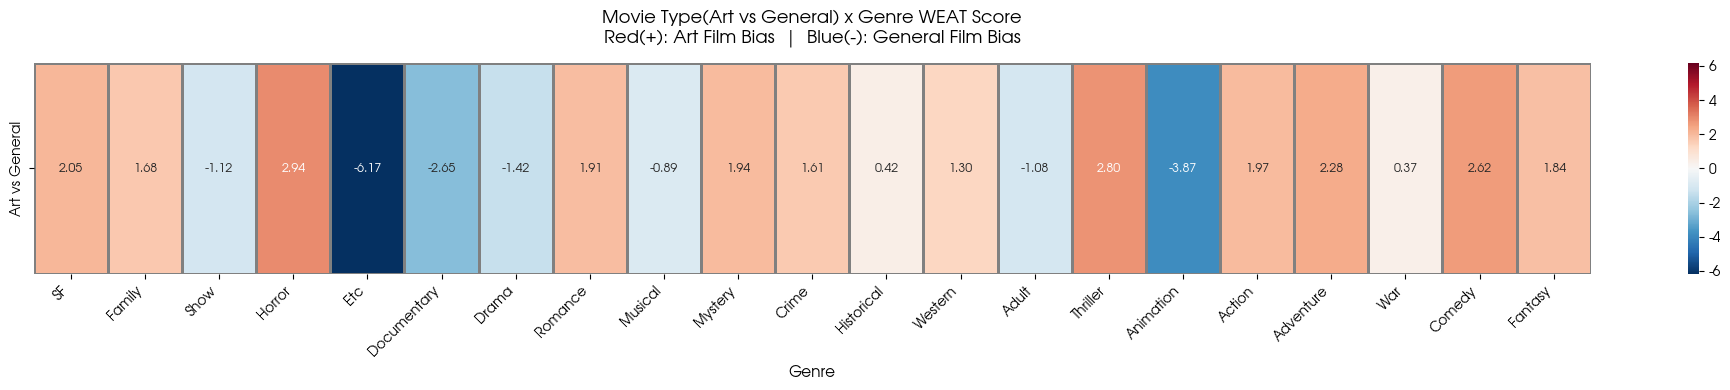

In [17]:
# 장르명 영문 매핑
genre_name_en = ['SF', 'Family', 'Show', 'Horror', 'Etc', 'Documentary',
                 'Drama', 'Romance', 'Musical', 'Mystery', 'Crime',
                 'Historical', 'Western', 'Adult', 'Thriller', 'Animation',
                 'Action', 'Adventure', 'War', 'Comedy', 'Fantasy']

score_matrix = np.array(weat_scores).reshape(1, -1)

fig, ax = plt.subplots(figsize=(20, 4))

sns.heatmap(
    score_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-max(abs(np.array(weat_scores))),
    vmax= max(abs(np.array(weat_scores))),
    xticklabels=genre_name_en,   # 영문 장르명 사용
    yticklabels=['Art vs General'],
    linewidths=0.8,
    linecolor='gray',
    annot_kws={'size': 9},
    ax=ax
)

ax.set_title('Movie Type(Art vs General) x Genre WEAT Score\n'
             'Red(+): Art Film Bias  |  Blue(-): General Film Bias',
             fontsize=13, pad=15)
ax.set_xlabel('Genre', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(data_dir + '/weat_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### 결과
1. 예상과 다르게 액션영화가 일반상업영화 편향이 예상되었으나 예술편향으로 나옴
2. 코미디영화는 상업영화 성격이 강하다고 생각했는데 예술편향으로 나옴
3. 공포영화는 장르 특성상 상업영화에 가깝지만 예술편향으로 나옴
4. 반면 다큐멘터리는 예술영화 성격이 강할 것 같지만 일반 편향으로 나옴
5. 에니메이션은 상업적 성격이 강함
6. 기타 가장 강한 일반 편향, 분류되지 않은 상업 장르 집합으로 추정

#### 회고
1. 많은 시행 착오와 하나 하나 함수와 기능을 따져보고 이해하는데 많은 시간이 걸렸음
2. 실행을 함에 있어서 시간이 꽤나 오래걸리고 한번 에러가 날때마다 다시 수정하고 보완하는데 많은 시간을 할애해야 하는 제한사항이 있었음
3. 아직도 관련 기능을 정확하고 명확하게 이해하기에는 너무 분량이 많은 관계로 개인적으로 다소 아쉬운 부분이 많은 프로젝트였음.